# Testing score plot

本 notebook 僅保留預測輸出後的評估作圖。

- Latent representation 相關內容已移至 `Notebook/Latent_representation_extraction.ipynb`。

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
print('Plot notebook ready')

In [ ]:
pred_csv = '../outputs/caco2_pipeline/caco2_predictions_with_gt.csv'
df = pd.read_csv(pred_csv)
print(df.head(3))
print('columns =', list(df.columns))

In [ ]:
def evaluate_regression(df, gt_col, pred_col):
    mae = mean_absolute_error(df[gt_col], df[pred_col])
    rmse = mean_squared_error(df[gt_col], df[pred_col], squared=False)
    r2 = r2_score(df[gt_col], df[pred_col])
    print({'mae': mae, 'rmse': rmse, 'r2': r2})

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(df[gt_col], df[pred_col], alpha=0.6)
    axes[0].set_xlabel('GT')
    axes[0].set_ylabel('Prediction')
    axes[0].set_title('GT vs Prediction')

    residual = df[pred_col] - df[gt_col]
    axes[1].hist(residual, bins=30)
    axes[1].set_title('Residual Distribution')
    axes[1].set_xlabel('Prediction - GT')
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_classification(df, gt_col, conf_col, threshold=0.5):
    y_true = df[gt_col].values
    y_score = df[conf_col].values
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    print({'roc_auc': roc_auc, 'pr_auc': pr_auc})

    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], '--')
    axes[0].set_title(f'ROC (AUC={roc_auc:.4f})')

    axes[1].plot(recall, precision)
    axes[1].set_title(f'PR (AUC={pr_auc:.4f})')
    plt.tight_layout()
    plt.show()

    pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix (threshold={threshold})')
    plt.show()

In [ ]:
# Regression 例子:
# evaluate_regression(df, gt_col='logPapp', pred_col='SCAGE_prediction_logPapp')

# Classification 例子:
# evaluate_classification(df, gt_col='Label', conf_col='SCAGE_confidence_Label', threshold=0.5)

# SCAGE Prediction Plot Notebook

此 notebook 僅用於預測輸出 CSV 的評估與作圖。

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)
print('Notebook ready')

In [ ]:
pred_csv = '../outputs/caco2_pipeline/caco2_predictions_with_gt.csv'
df = pd.read_csv(pred_csv)
print(df.head(3))
print('columns =', list(df.columns))

In [ ]:
def evaluate_regression(df, gt_col, pred_col):
    mae = mean_absolute_error(df[gt_col], df[pred_col])
    rmse = mean_squared_error(df[gt_col], df[pred_col], squared=False)
    r2 = r2_score(df[gt_col], df[pred_col])
    print({'mae': mae, 'rmse': rmse, 'r2': r2})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(df[gt_col], df[pred_col], alpha=0.6)
    axes[0].set_xlabel('GT')
    axes[0].set_ylabel('Prediction')
    axes[0].set_title('GT vs Prediction')
    residual = df[pred_col] - df[gt_col]
    axes[1].hist(residual, bins=30)
    axes[1].set_title('Residual Distribution')
    axes[1].set_xlabel('Prediction - GT')
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_classification(df, gt_col, conf_col, threshold=0.5):
    y_true = df[gt_col].values
    y_score = df[conf_col].values
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    print({'roc_auc': roc_auc, 'pr_auc': pr_auc})
    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], '--')
    axes[0].set_title(f'ROC (AUC={roc_auc:.4f})')
    axes[1].plot(recall, precision)
    axes[1].set_title(f'PR (AUC={pr_auc:.4f})')
    plt.tight_layout()
    plt.show()
    pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix (threshold={threshold})')
    plt.show()

In [ ]:
# Regression example:
# evaluate_regression(df, gt_col='logPapp', pred_col='SCAGE_prediction_logPapp')

# Classification example:
# evaluate_classification(df, gt_col='Label', conf_col='SCAGE_confidence_Label', threshold=0.5)

# Evaluate Score Plot Notebook

本 notebook 只保留「模型預測輸出後的指標與圖表繪製」。

- Latent representation 抽取流程已搬移到：`Notebook/Latent_representation_extraction.ipynb`
- 這裡建議直接讀取 pipeline 產出的 `*_predictions_with_gt.csv` 進行視覺化。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print('Plot-only notebook ready')

[Init] PROJECT_ROOT = /workspace
[Init] CWD switched to = /workspace


In [2]:
# 請改成你的 pipeline 輸出
# regression 範例欄位: GT + SCAGE_prediction_xxx
# classification 範例欄位: GT + SCAGE_confidence_xxx
pred_csv = '../outputs/caco2_pipeline/caco2_predictions_with_gt.csv'
df = pd.read_csv(pred_csv)
print(df.head(3))
print('columns =', list(df.columns))

Imports loaded


In [3]:
def evaluate_regression(df, gt_col, pred_col):
    mae = mean_absolute_error(df[gt_col], df[pred_col])
    rmse = mean_squared_error(df[gt_col], df[pred_col], squared=False)
    r2 = r2_score(df[gt_col], df[pred_col])
    print({'mae': mae, 'rmse': rmse, 'r2': r2})

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(df[gt_col], df[pred_col], alpha=0.6)
    axes[0].set_xlabel('GT')
    axes[0].set_ylabel('Prediction')
    axes[0].set_title('GT vs Prediction')

    residual = df[pred_col] - df[gt_col]
    axes[1].hist(residual, bins=30)
    axes[1].set_title('Residual Distribution')
    axes[1].set_xlabel('Prediction - GT')
    plt.tight_layout()
    plt.show()


def evaluate_classification(df, gt_col, conf_col, threshold=0.5):
    y_true = df[gt_col].values
    y_score = df[conf_col].values
    auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    print({'roc_auc': auc, 'pr_auc': ap})

    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], '--')
    axes[0].set_title(f'ROC (AUC={auc:.4f})')

    axes[1].plot(recall, precision)
    axes[1].set_title(f'PR (AUC={ap:.4f})')
    plt.tight_layout()
    plt.show()

    pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix (threshold={threshold})')
    plt.show()

In [4]:
# Regression 例子（例如 caco2 / iv_hcl / iv_hvdss）
# evaluate_regression(df, gt_col='logPapp', pred_col='SCAGE_prediction_logPapp')

# Classification 例子（例如 rliver_mstability_binary）
# evaluate_classification(df, gt_col='Label', conf_col='SCAGE_confidence_Label', threshold=0.5)
print('請取消註解並填入正確欄位名稱後執行。')

===== SCAGE Finetune (MPP head) =====
mode: finetune
atom_embed_dim (D): 512
layer_num: 6
num_heads: 16
hidden_size (FFN): 256
num_tasks: 1
total params: 21,398,502
trainable params: 21,398,502

[Backbone]
 - atom_feature: AtomEmbedding
 - EncoderAtomList: 6 x EncoderAtomLayer

[Heads]
 - head_Graph: AtomProjection
 - head_finger_keeping_atom: AtomProjection
 - head_finger_keeping_bond: AtomProjection
 - head_FG_atom: AtomFGProjection


===== SCAGE Pretrain (self-supervised heads) =====
mode: pretrain_bin
pretrain_task: ['finger', 'sp', 'angle', 'fg']
atom_embed_dim (D): 512
layer_num: 6
num_heads: 16
hidden_size (FFN): 256
num_tasks: 1
total params: 19,054,252
trainable params: 19,054,252

[Backbone]
 - atom_feature: AtomEmbedding
 - EncoderAtomList: 6 x EncoderAtomLayer

[Heads]
 - head_FG_atom: AtomFGProjection
 - head_finger_keeping_atom: AtomProjection
 - head_pair_distances: AtomPairProjectionBin
 - head_angle: AtomAngleProjectionBin


## 說明

本 notebook 僅做「預測輸出後」的評估與視覺化。

Latent representation 抽取內容已移至：
- `Notebook/Latent_representation_extraction.ipynb`

In [5]:
# Latent 抽取 cell 已移至 Notebook/Latent_representation_extraction.ipynb

AtomEmbedding output shape: (3, 7, 512)
After encoder layer 1: (3, 7, 512)
After encoder layer 2: (3, 7, 512)
After encoder layer 3: (3, 7, 512)
After encoder layer 4: (3, 7, 512)
After encoder layer 5: (3, 7, 512)
After encoder layer 6: (3, 7, 512)
graph_token shape: (3, 512)
atom_tokens shape: (3, 6, 512)
atom_mean shape: (3, 512)
failed smiles: []


In [7]:
# Latent 抽取 cell 已移至 Notebook/Latent_representation_extraction.ipynb

In [ ]:
# ===== 路徑設定（可直接改） =====
pretrain_ckpt = './weights/pretrain/pretrain.pth'
mpp_ckpt = './weights/mpp/bace.pth'
input_csv = './data/mpp/custom/GDSC_drug_merge_pubchem_dropNA_MACCS.csv'
smiles_col = 'SMILES'
id_col = 'drug_name'
max_rows = 128  # demo 用，避免一次太大


def pca_2d(x: np.ndarray) -> np.ndarray:
    x = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x, full_matrices=False)
    w = vt[:2].T
    return x @ w


# 1) 從 CSV 建立輸入（保留 drug_name / row_id）
df = pd.read_csv(input_csv).head(max_rows).copy()
if smiles_col not in df.columns:
    raise ValueError(f'CSV missing smiles column: {smiles_col}')

if id_col not in df.columns:
    print(f'[WARN] {id_col} not found, fallback to row_id')
    df[id_col] = None

smiles_list = df[smiles_col].astype(str).tolist()

# 2) 抽 latent（目前函式輸入是 smiles list）
latent_pre = None
latent_mpp = None

if os.path.exists(pretrain_ckpt):
    latent_pre = extract_latent_from_smiles(smiles_list, pretrain_ckpt, task_name='bace', batch_size=16)
    print('pretrain graph_token shape:', latent_pre['graph_token'].shape)
else:
    print('[WARN] pretrain checkpoint not found:', pretrain_ckpt)

if os.path.exists(mpp_ckpt):
    latent_mpp = extract_latent_from_smiles(smiles_list, mpp_ckpt, task_name='bace', batch_size=16)
    print('mpp graph_token shape:', latent_mpp['graph_token'].shape)
else:
    print('[WARN] mpp checkpoint not found:', mpp_ckpt)

# 3) 依 failed index 建立 valid row metadata，對齊 embedding 順序
def make_valid_meta(df_: pd.DataFrame, failed_list):
    failed_idx = set([i for i, _ in failed_list])
    meta_rows = []
    for i, row in df_.iterrows():
        if i in failed_idx:
            continue
        drug_name = row[id_col] if id_col in df_.columns and pd.notna(row[id_col]) else None
        rid = int(i)
        uid = str(drug_name).strip() if drug_name is not None and str(drug_name).strip() != '' else f'row_{rid}'
        meta_rows.append({'id': uid, 'row_id': rid, 'drug_name': drug_name, 'smiles': row[smiles_col]})
    return meta_rows

if latent_pre is not None:
    pre_meta = make_valid_meta(df, latent_pre['failed_smiles'])
    print('valid pretrain records:', len(pre_meta))
if latent_mpp is not None:
    mpp_meta = make_valid_meta(df, latent_mpp['failed_smiles'])
    print('valid mpp records:', len(mpp_meta))

# 4) pretrain vs mpp 分佈比較
if latent_pre is not None and latent_mpp is not None:
    z_pre = latent_pre['graph_token']
    z_mpp = latent_mpp['graph_token']

    z_pre_2d = pca_2d(z_pre)
    z_mpp_2d = pca_2d(z_mpp)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(z_pre_2d[:, 0], z_pre_2d[:, 1], c='tab:blue')
    axes[0].set_title('Pretrain graph_token PCA (CSV input)')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')

    axes[1].scatter(z_mpp_2d[:, 0], z_mpp_2d[:, 1], c='tab:orange')
    axes[1].set_title('MPP graph_token PCA (CSV input)')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')

    plt.tight_layout()
    plt.show()

    print('Pretrain failed SMILES:', latent_pre['failed_smiles'][:5])
    print('MPP failed SMILES:', latent_mpp['failed_smiles'][:5])

In [3]:
# ===== 讀取 extract_latent.py 輸出（records-only pkl）範例 =====
# extract_latent.py 與 extract_latent_from_smiles(return_atom_tokens=True) 目前將
# atom_tokens / atom_mask 存成「每個分子一個 ndarray」（長度隨原子數而變），
# 無法直接用 np.stack 組成固定 [N, A, D]，需先 pad 到全域 max_atoms。
import pickle

latent_pkl_path = './result/gdsc_pretrain_latent.pkl'  # 由 extract_latent.py 產生
if os.path.exists(latent_pkl_path):
    with open(latent_pkl_path, 'rb') as f:
        records = pickle.load(f)  # list[dict]

    print('output type:', type(records).__name__)
    print('records count:', len(records))

    # 取第一筆示範（單筆記錄）
    first = records[0]
    print('first record keys:', list(first.keys()))
    print('first id:', first['id'])
    print('graph_token shape:', np.asarray(first['graph_token']).shape)
    print('atom_mean shape:', np.asarray(first['atom_mean']).shape)
    # 每筆 atom_tokens 為 [n_atoms, D]，與 extract_latent.py 一致
    print('atom_tokens shape (sample 0):', np.asarray(first['atom_tokens']).shape)
    print('atom_mask shape (sample 0):', np.asarray(first['atom_mask']).shape)

    def pad_atom_batches(records_):
        """將每筆可變長 atom_tokens pad 成 [N, max_A, D]、atom_mask 成 [N, max_A]。"""
        emb_d = int(np.asarray(records_[0]['atom_tokens']).shape[-1])
        lengths = [int(np.asarray(r['atom_tokens']).shape[0]) for r in records_]
        max_a = max(lengths) if lengths else 0
        n = len(records_)
        atom_tokens_3d = np.zeros((n, max_a, emb_d), dtype=np.float32)
        atom_mask_2d = np.zeros((n, max_a), dtype=np.float32)
        for i, r in enumerate(records_):
            at = np.asarray(r['atom_tokens'], dtype=np.float32)
            am = np.asarray(r['atom_mask'], dtype=np.float32)
            li = at.shape[0]
            if li > 0:
                atom_tokens_3d[i, :li] = at
                atom_mask_2d[i, :li] = am
        return atom_tokens_3d, atom_mask_2d, max_a, emb_d

    graph_token_2d = np.stack([r['graph_token'] for r in records], axis=0)  # [N, D]
    atom_mean_2d = np.stack([r['atom_mean'] for r in records], axis=0)      # [N, D]
    atom_tokens_3d, atom_mask_2d, max_atoms, emb_d = pad_atom_batches(records)

    n, a, d = atom_tokens_3d.shape
    atom_tokens_2d = atom_tokens_3d.reshape(n, a * d)                       # [N, max_A*D]

    print('\n[Array views]')
    print('graph_token_2d:', graph_token_2d.shape)
    print('atom_mean_2d:', atom_mean_2d.shape)
    print('atom_tokens_3d (padded):', atom_tokens_3d.shape, ' max_atoms=', max_atoms, ' D=', emb_d)
    print('atom_mask_2d (padded):', atom_mask_2d.shape)
    print('atom_tokens_2d:', atom_tokens_2d.shape)

    # 依 id 快速建立索引
    by_id = {r['id']: r for r in records}
    vec = by_id[first['id']]['graph_token']
    print('vector fetched by id shape:', np.asarray(vec).shape)
else:
    print('[INFO] file not found:', latent_pkl_path)
    print('請先執行: python extract_latent.py --weights ... --smiles_csv ... --output ./result/bace_small_records_only.pkl')

output type: list
records count: 421
first record keys: ['id', 'row_id', 'drug_name', 'smiles', 'graph_token', 'atom_mean', 'atom_tokens', 'atom_mask']
first id: (5z)-7-oxozeaenol
graph_token shape: (512,)
atom_mean shape: (512,)
atom_tokens shape (sample 0): (26, 512)
atom_mask shape (sample 0): (26,)

[Array views]
graph_token_2d: (421, 512)
atom_mean_2d: (421, 512)
atom_tokens_3d (padded): (421, 96, 512)  max_atoms= 96  D= 512
atom_mask_2d (padded): (421, 96)
atom_tokens_2d: (421, 49152)
vector fetched by id shape: (512,)


In [4]:
# ===== 新版命令建議（records-only 輸出） =====
print('建議執行：')
print('python extract_latent.py --weights ./weights/mpp/bace.pth --smiles_csv ./data/mpp/raw/bace.csv --smiles_col smiles --id_col drug_name --output ./result/bace_records_only.pkl')
print('\n說明：')
print('- weight_type 預設 auto：會從權重路徑/名稱判斷 pretrain 或 mpp')
print('- task 參數可省略：mpp 權重會從檔名推斷，例如 bace.pth -> bace')
print('- 輸出是 list[dict]，只保留 records，方便後續直接使用')
print('- 每筆包含 id / row_id / drug_name / smiles / graph_token / atom_mean / atom_tokens / atom_mask')
print('- atom_tokens / atom_mask 為每個分子可變長度 [n_atoms, D] / [n_atoms]；若要 [N,A,D] 張量請自行 pad（見上方讀取範例）')

建議執行：
python extract_latent.py --weights ./weights/mpp/bace.pth --smiles_csv ./data/mpp/raw/bace.csv --smiles_col smiles --id_col drug_name --output ./result/bace_records_only.pkl

說明：
- weight_type 預設 auto：會從權重路徑/名稱判斷 pretrain 或 mpp
- task 參數可省略：mpp 權重會從檔名推斷，例如 bace.pth -> bace
- 輸出是 list[dict]，只保留 records，方便後續直接使用
- 每筆包含 id / row_id / drug_name / smiles / graph_token / atom_mean / atom_tokens / atom_mask


# Testing score plot

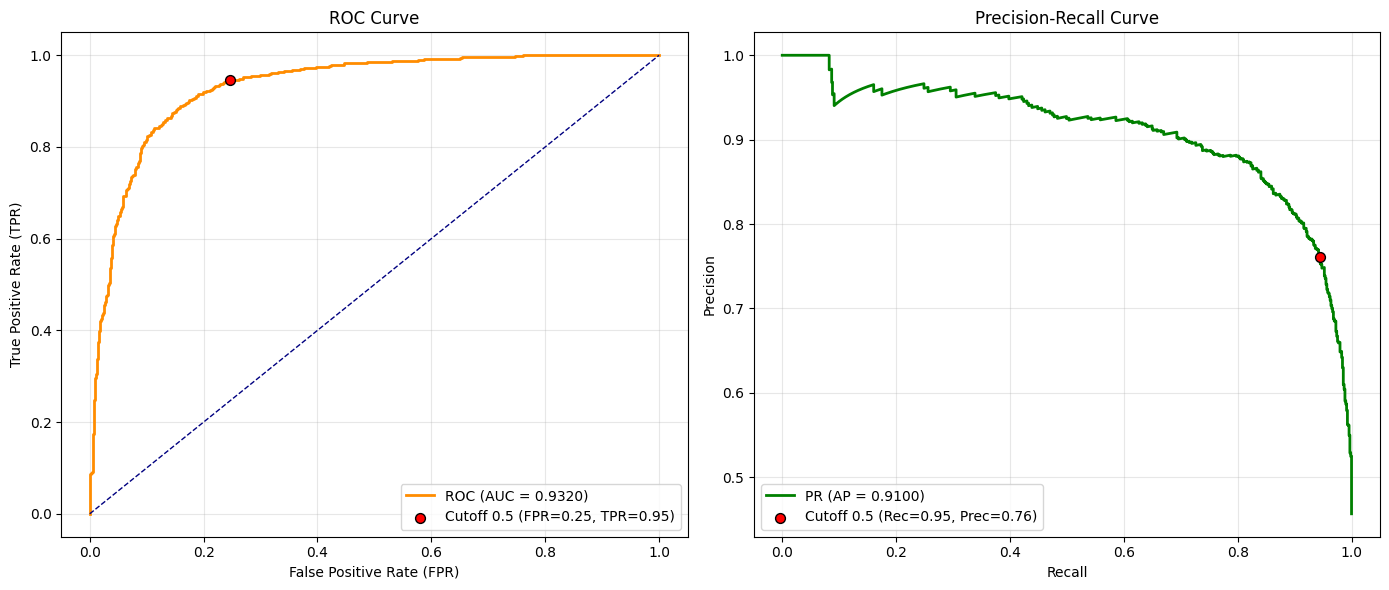

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# 1. 讀取資料與計算指標
df = pd.read_csv('../result/bace.csv')
y_true = df['Class']
y_scores = df['SCAGE_confidence_Class']
cutoff = 0.5

auc_value = roc_auc_score(y_true, y_scores)
ap_value = average_precision_score(y_true, y_scores)

# 2. 取得曲線數據
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

# 3. 尋找最接近 0.5 Cutoff 的索引點
idx_roc = np.argmin(np.abs(roc_thresholds - cutoff))
idx_pr = np.argmin(np.abs(pr_thresholds - cutoff))

# 4. 繪圖
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- 左圖：ROC Curve ---
ax1.plot(fpr, tpr, label=f'ROC (AUC = {auc_value:.4f})', color='darkorange', lw=2)
ax1.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
# 標出 0.5 點
ax1.scatter(fpr[idx_roc], tpr[idx_roc], color='red', s=50, edgecolors='black', zorder=5, 
            label=f'Cutoff 0.5 (FPR={fpr[idx_roc]:.2f}, TPR={tpr[idx_roc]:.2f})')

ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- 右圖：PR Curve ---
ax2.plot(recall, precision, label=f'PR (AP = {ap_value:.4f})', color='green', lw=2)
# 標出 0.5 點
ax2.scatter(recall[idx_pr], precision[idx_pr], color='red', s=50, edgecolors='black', zorder=5, 
            label=f'Cutoff 0.5 (Rec={recall[idx_pr]:.2f}, Prec={precision[idx_pr]:.2f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('../result/bace.csv')

# 設定信心值閾值 (Threshold)，將信心值轉換為預測類別 (0 或 1)
threshold = 0.5
df['pred_label'] = (df['SCAGE_confidence_Class'] >= threshold).astype(int)

# 計算主要指標 (Precision, Recall, F1-score, Support)
report = classification_report(df['Class'], df['pred_label'], output_dict=True, digits=2)
report_df = pd.DataFrame(report).transpose()
print(report_df)

              precision    recall  f1-score      support
0              0.941985  0.750608  0.835477   822.000000
1              0.761072  0.945007  0.843125   691.000000
accuracy       0.839392  0.839392  0.839392     0.839392
macro avg      0.851528  0.847808  0.839301  1513.000000
weighted avg   0.859360  0.839392  0.838970  1513.000000


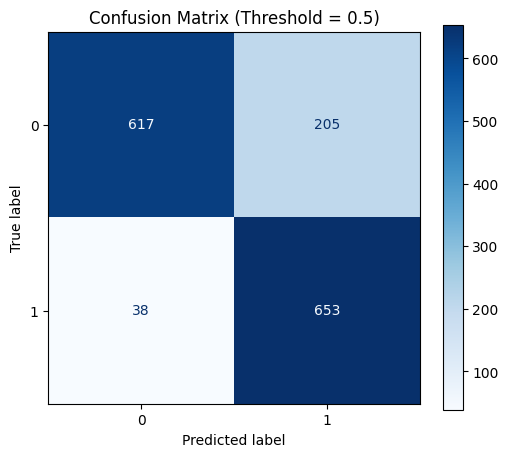

真陰性 (TN): 617, 偽陽性 (FP): 205
偽陰性 (FN): 38, 真陽性 (TP): 653


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 計算混淆矩陣
cm = confusion_matrix(df['Class'], df['pred_label'])

# 2. 設定繪圖格式
# display_labels 可以根據你的類別名稱自訂，例如 ['Negative', 'Positive']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

# 3. 繪圖
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d') # values_format='d' 顯示整數

plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

# 如果需要獲取具體數值
tn, fp, fn, tp = cm.ravel()
print(f"真陰性 (TN): {tn}, 偽陽性 (FP): {fp}")
print(f"偽陰性 (FN): {fn}, 真陽性 (TP): {tp}")